# Pandas

[Pandas](https://pandas.pydata.org/) is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

## Einleitung

Key Features:
- Pandas untersützt eine Vielzahl von Dateiformaten zum lesen und schreiben von Daten
- Pandas bietet zwei Hauptstrukturen:
  - Series (1D-Daten, ähnlich wie eine Spalte)
  - DataFrame (2D-Tabelle, ähnlich wie Excel)
- Ermöglicht schnelles Filtern, Gruppieren, Umformen und Visualisieren von Daten.
- Das Pandas DataFrame (analog dem DataFrame in R) eignet sich hervorragend für das Arbeint mit 2 dimensonalen Daten wie sie oft in CSV, Excel oder Datenbank Tabellen vorliegen.


In [56]:
import numpy as np      # Numpy wird oft mit alias np importiert
import pandas as pd     # Pandas wird oft mit alias pd importiert

## Datenstrukturen

### Series

Pandes Series bilden 1 dimensionale Daten ab.

In [57]:
import numpy as np
import pandas as pd

s1 = pd.Series([10, 20, 30])
s2 = pd.Series([10, 20, 30], index=["a", "b", "c"])

print("Series s1:")
print(s1)

print("Series s2 mit Index:")
print(s2)

print("Zugriff s1 via Index:", s1[1])
print("Zugriff s2 mit Index:", s2["b"])

Series s1:
0    10
1    20
2    30
dtype: int64
Series s2 mit Index:
a    10
b    20
c    30
dtype: int64
Zugriff s1 via Index: 20
Zugriff s2 mit Index: 20


### DataFrame

Pandas DateFrame bilden 2 dimensionale Daten ab.

In [39]:
data = {
    "Name": ["Anna", "Ben", "Clara", "Sam"],
    "Alter": [23, 35, 29, 24],
    "Stadt": ["Zürich", "Bern", "Basel", "Bern"]
}
df = pd.DataFrame(data)
print(df)


    Name  Alter   Stadt
0   Anna     23  Zürich
1    Ben     35    Bern
2  Clara     29   Basel
3    Sam     24    Bern


In [44]:
print("Zweite Zeile via Label (hier die Row Nummer, da keine explizite Namen vergeben wurden):")
print(df.loc[2])


Zweite Zeile via Label (hier die Row Nummer, da keine explizite Namen vergeben wurden):
Name     Clara
Alter       29
Stadt    Basel
Name: 2, dtype: object


## Daten lesen und schreiben

Pandas verfügt über eine Vielzahl von Funktionen zum Einlesen und Schreiben von Daten. Es werden viele verschieden Formate unterstützt, wie zum Beispiel:

**CSV lesen**
```
df_csv = pd.read_csv('daten.csv')

# Spezielle Parameter (falls die Datei z.B. Semikolons nutzt)
df_csv = pd.read_csv('daten.csv', sep=';', encoding='utf-8')
```

**Excel lesen**
```
# Erfordert oft die Bibliothek 'openpyxl'
df_excel = pd.read_excel('budget.xlsx', sheet_name='Tabelle1')
```

**Excel schreiben**
```
# Speichern als Excel-Datei ohne den Zeilenindex
df.to_excel('bereinigte_daten.xlsx', index=False)
```

## Daten inspizieren

Mit den folgenden Befehlen kann ein erster Blick auf die Daten geworfen werden:
- **df.head(n)**    : Zeigt die ersten n Zeilen an.
- **df.info()**     : Zeigt Datentypen und ob Werte fehlen (Non-Null Count).
- **df.describe()** : Berechnet statistische Kennzahlen wie Mittelwert, Standardabweichung und Quartile.

### head

In [46]:
df.head()       # df.head(n) zeigt die ersten n Einträge

,Name,Alter,Stadt
0,Anna,23,Zürich
1,Ben,35,Bern
2,Clara,29,Basel
3,Sam,24,Bern


### info

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Name    4 non-null      object
 1   Alter   4 non-null      int64 
 2   Stadt   4 non-null      object
dtypes: int64(1), object(2)
memory usage: 224.0+ bytes


### describe

In [48]:
df.describe()

,Alter
count,4.00
mean,27.75
std,5.50
min,23.00
25%,23.75
50%,26.50
75%,30.50
max,35.00


## Daten auswählen

In [58]:
data = {
    "Name": ["Anna", "Ben", "Clara", "Sam"],
    "Alter": [23, 35, 29, 24],
    "Stadt": ["Zürich", "Bern", "Basel", "Bern"]
}
df = pd.DataFrame(data)
print(df)

    Name  Alter   Stadt
0   Anna     23  Zürich
1    Ben     35    Bern
2  Clara     29   Basel
3    Sam     24    Bern


### Spalte per Name auswählen

In [59]:
print("Namen:")
print(df["Name"])

Namen:
0     Anna
1      Ben
2    Clara
3      Sam
Name: Name, dtype: object


### Zeilen/Spalten per Position auswählen

**iloc**

Mit iloc können Zeilen und Spalten via **Integer-Position** selektiert werden. Der End-Index wird nicht eingeschlossen (gleich wie bei Python Listen).


**Syntax:**

**iloc[row-range, col-range]** (End-Index exklusiv)

In [60]:
print("Erste Zeile:")
print(df.iloc[0])

Erste Zeile:
Name       Anna
Alter        23
Stadt    Zürich
Name: 0, dtype: object


In [61]:
print("Dritte Spalte:")
print(df.iloc[:,2])

Dritte Spalte:
0    Zürich
1      Bern
2     Basel
3      Bern
Name: Stadt, dtype: object


In [62]:
print("Zeilen 0 + 1, Spalten 0 + 1:")
print(df.iloc[0:2, 0:2])

Zeilen 0 + 1, Spalten 0 + 1:
   Name  Alter
0  Anna     23
1   Ben     35


### Zeilen/Spalten per Label auswählen

**loc**

Mit loc können Zeilen und Spalten via **Label** selektiert werden. Der End-Index wird eingeschlossen.

**Syntax:**

**loc[row-label, col-label]** (End-Label inclusiv)



In [63]:
print("Zweite Zeile via Label (hier die Row Nummer, da keine explizite Namen vergeben wurden):")
print(df.loc[2])

Zweite Zeile via Label (hier die Row Nummer, da keine explizite Namen vergeben wurden):
Name     Clara
Alter       29
Stadt    Basel
Name: 2, dtype: object


In [64]:
print("Zeilen 0-2, Spalten Name und Stadt:")
print(df.loc[0:2, ["Name", "Stadt"]])

Zeilen 0-2, Spalten Name und Stadt:
    Name   Stadt
0   Anna  Zürich
1    Ben    Bern
2  Clara   Basel


## Daten analysieren

In [65]:
data = {
    "Name": ["Anna", "Ben", "Clara", "Sam"],
    "Alter": [23, 35, 29, 24],
    "Stadt": ["Zürich", "Bern", "Basel", "Bern"]
}
df = pd.DataFrame(data)
print(df)

    Name  Alter   Stadt
0   Anna     23  Zürich
1    Ben     35    Bern
2  Clara     29   Basel
3    Sam     24    Bern


### Sortieren

In [67]:
# Sortieren nach Alter absteigend
df_sorted = df.sort_values(by="Alter", ascending=False)
print(df_sorted)

    Name  Alter   Stadt
1    Ben     35    Bern
2  Clara     29   Basel
3    Sam     24    Bern
0   Anna     23  Zürich


### Filtern

In [68]:
print("Alle Personen älter als 25:")
print(df[df["Alter"] > 25])


Alle Personen älter als 25:
    Name  Alter  Stadt
1    Ben     35   Bern
2  Clara     29  Basel


In [69]:
# Personen unter 30 in Bern
filter_df = df[(df["Alter"] < 30) & (df["Stadt"] == "Bern")]
print(filter_df)

  Name  Alter Stadt
3  Sam     24  Bern


### Gruppieren

**GroupBy**
- Mit der groupby Methode werden Daten nach einer Spalte gruppiert
- Man kann dann auf dem zurückgegebenen Objekt Funktionen pro Gruppe anwenden

In [70]:
# Gruppieren nach Stadt, dann Filtern nach Alter und Berechnung von Mittelwert und Anzahl
stadt_analyse = df.groupby("Stadt")["Alter"].agg(["mean", "count"])

# Spalten umbenennen für bessere Lesbarkeit
stadt_analyse.columns = ["Durchschnittsalter", "Anzahl Personen"]

print(stadt_analyse)

        Durchschnittsalter  Anzahl Personen
Stadt                                      
Basel                 29.0                1
Bern                  29.5                2
Zürich                23.0                1


## Daten transformieren

In [136]:
data = {
    "Name" : ["Anna", "Ben", "Clara", "Sam"],
    "Alter": [12, 17, 18, 24],
    "Ort"  : ["Bern", "Biel", "Lausanne", "Montreux"]
}
df = pd.DataFrame(data)
print(df)


    Name  Alter       Ort
0   Anna     12      Bern
1    Ben     17      Biel
2  Clara     18  Lausanne
3    Sam     24  Montreux


### Daten hinzufügen

In [137]:
# Zeile hinzufügen
df.loc[len(df)] = ["Lea", 24, "Bern"]
print(df)

    Name  Alter       Ort
0   Anna     12      Bern
1    Ben     17      Biel
2  Clara     18  Lausanne
3    Sam     24  Montreux
4    Lea     24      Bern


In [138]:
# Spalte hinzufügen mit Wert basierend auf einer Bedingung
df["Volljährig"] = df["Alter"] >= 18
print(df)

    Name  Alter       Ort  Volljährig
0   Anna     12      Bern       False
1    Ben     17      Biel       False
2  Clara     18  Lausanne        True
3    Sam     24  Montreux        True
4    Lea     24      Bern        True


### Daten bearbeiten

In [139]:
# Einzelner Wert ändern:
df.loc[0, "Alter"] = 14     # ändert das Alter in der ersten Zeile auf 14

In [140]:
# Ben zügelt nach Lausanne
df.loc[df["Name"] == "Ben", "Ort"] = "Lausanne"
print(df)

    Name  Alter       Ort  Volljährig
0   Anna     14      Bern       False
1    Ben     17  Lausanne       False
2  Clara     18  Lausanne        True
3    Sam     24  Montreux        True
4    Lea     24      Bern        True


### Daten ersetzen

- Verwenden Sie df = df.replace(...), wenn das gesamte DataFrame nach einem Wort durchsucht werden soll.
- Verwenden Sie df["Spalte"] = df["Spalte"].replace(...), wenn die Änderung präzise nur eine Spalte betreffen soll.

In [141]:
df["Ort"] = df["Ort"].replace("Lausanne", "Zürich")
print(df)

    Name  Alter       Ort  Volljährig
0   Anna     14      Bern       False
1    Ben     17    Zürich       False
2  Clara     18    Zürich        True
3    Sam     24  Montreux        True
4    Lea     24      Bern        True


### Daten umbenennen

In [142]:
df = df.rename(columns={"Alter": "Lebensalter"})
print(df)

    Name  Lebensalter       Ort  Volljährig
0   Anna           14      Bern       False
1    Ben           17    Zürich       False
2  Clara           18    Zürich        True
3    Sam           24  Montreux        True
4    Lea           24      Bern        True


### Datentyp ändern

In [143]:
df["Lebensalter"] = df["Lebensalter"].astype(float)
print(df)

    Name  Lebensalter       Ort  Volljährig
0   Anna         14.0      Bern       False
1    Ben         17.0    Zürich       False
2  Clara         18.0    Zürich        True
3    Sam         24.0  Montreux        True
4    Lea         24.0      Bern        True


### Daten löschen

Zum Löschen von Daten wird meist die Methode `drop` verwendet.

Beispiele:
- Spalte löschen: df = df.drop(columns=["Alter_in_10_Jahren"]) entfernt die Hilfsspalte wieder.
- Zeile löschen: df = df.drop(index=0) löscht die erste Zeile.
- Duplikate entfernen: df = df.drop_duplicates() ist sehr nützlich, wenn Daten doppelt vorkommen

In [144]:
# Spalten Alter und Volljähring löschnen
df = df.drop(columns=["Lebensalter", "Volljährig"])
print(df)

    Name       Ort
0   Anna      Bern
1    Ben    Zürich
2  Clara    Zürich
3    Sam  Montreux
4    Lea      Bern


In [145]:
# Zeile 1 löschen
df = df.drop(index=1)
print(df)

    Name       Ort
0   Anna      Bern
2  Clara    Zürich
3    Sam  Montreux
4    Lea      Bern


In [146]:
# Duplikat hinzufügen
df.loc[1] = ["Lea", "Bern"]
print(df)

    Name       Ort
0   Anna      Bern
2  Clara    Zürich
3    Sam  Montreux
4    Lea      Bern
1    Lea      Bern


In [147]:
# Duplikate löschen
df = df.drop_duplicates()
print(df)

    Name       Ort
0   Anna      Bern
2  Clara    Zürich
3    Sam  Montreux
4    Lea      Bern


### Funktion anwenden

**apply**

Mit apply kann eine Funktion auf jedes Element einer Serie oder eines DataFrame angewendet werden:

**Beispiel mit neuer Spalte**

In [148]:
data = {
    "Name" : ["Anna", "Ben", "Clara", "Sam"],
    "Alter": [12, 17, 18, 24],
    "Ort"  : ["Bern", "Biel", "Lausanne", "Montreux"]
}
df = pd.DataFrame(data)

def status_check(alter):
    if alter < 13:
        return "Kind"
    elif alter < 18:
        return "Jugendlich"
    else:
        return "Erwachsen"

df["Status"] = df["Alter"].apply(status_check)
print(df)


    Name  Alter       Ort      Status
0   Anna     12      Bern        Kind
1    Ben     17      Biel  Jugendlich
2  Clara     18  Lausanne   Erwachsen
3    Sam     24  Montreux   Erwachsen


**Beispiel mit bestehenden Werten**

In [80]:
col_names = ["A", "B", "C"]
row_names = ["First", "Second", "Third"]
data = [[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]]

print("Original DataFrame:")
df = pd.DataFrame(data, row_names, col_names)
print(df)

print("\nApply sqrt auf jedes original Element:")
sqrt_df = df.apply(np.sqrt)
print(sqrt_df)

print("\nApply square auf jedes original Element mit Lambda:")
square_df = df.apply(lambda x: x ** 2)
print(square_df)


Original DataFrame:
        A  B  C
First   1  2  3
Second  4  5  6
Third   7  8  9

Apply sqrt auf jedes original Element:
               A         B         C
First   1.000000  1.414214  1.732051
Second  2.000000  2.236068  2.449490
Third   2.645751  2.828427  3.000000

Apply square auf jedes original Element mit Lambda:
         A   B   C
First    1   4   9
Second  16  25  36
Third   49  64  81


## Daten mit fehlenden Werten

In [149]:
data = {
    "Name": ["Anna", "Ben", "Clara"],
    "Alter": [23, None, 29],
    "Einkommen": [4500, 5500, None]
}
df_nan = pd.DataFrame(data)
print(df_nan)

    Name  Alter  Einkommen
0   Anna   23.0     4500.0
1    Ben    NaN     5500.0
2  Clara   29.0        NaN


### Daten auf NaN Werte prüfen

In [150]:
# Prüfen, wo Werte fehlen (True/False Tabelle)
print(df_nan.isna())

    Name  Alter  Einkommen
0  False  False      False
1  False   True      False
2  False  False       True


In [151]:
# Summe der fehlenden Werte pro Spalte
print(df_nan.isna().sum())

Name         0
Alter        1
Einkommen    1
dtype: int64


### Mathematische Operationen

Pandas ignoriert NaN standardmäßig bei mathematischen Operationen.

In [152]:
print("Durchschnittseinkommen (ohne NaN):", df_nan["Einkommen"].mean())
print("Durchschnittsalter     (ohne NaN):", df_nan["Alter"].mean())

Durchschnittseinkommen (ohne NaN): 5000.0
Durchschnittsalter     (ohne NaN): 26.0


### Zeilen mit NaN Werten löschen

In [153]:
df_dropped = df_nan.dropna()
print(df_dropped)

   Name  Alter  Einkommen
0  Anna   23.0     4500.0


### NaN mit 0 ersetzen

Möchte man die Datensätze nicht verlieren, können die NaN mit 0 ersetzt werden.

In [154]:
df_nulled = df_nan.fillna(0)
print(df_nulled)

    Name  Alter  Einkommen
0   Anna   23.0     4500.0
1    Ben    0.0     5500.0
2  Clara   29.0        0.0


### NaN mit mean ersetzen

Warum diese Methode?

- Erhalt der Daten: Im Gegensatz zu dropna() (Löschen) bleibt die Zeile für "Ben" oder "Clara" erhalten.
- Statistische Neutralität: Das Ersetzen durch den Mittelwert verfälscht den Gesamtdurchschnitt der Spalte nicht, was für viele Analysen wichtig ist.
- Flexibilität: Mit fillna(0) würden Sie alle Lücken mit Null füllen, was beim Einkommen oft die Statistik verfälscht.

In [155]:
df_mean = df_nan.copy()

# Mittelwerte berechnen (Pandas ignoriert NaN dabei automatisch)
mean_alter = df_nan["Alter"].mean()
mean_einkommen = df_nan["Einkommen"].mean()

# Gezielte Ersetzung pro Spalte
df_mean["Alter"]     = df_nan["Alter"].fillna(mean_alter)
df_mean["Einkommen"] = df_mean["Einkommen"].fillna(mean_einkommen)

print("Nach der Ersetzung mit dem Mittelwert:")
print(df_mean)

Nach der Ersetzung mit dem Mittelwert:
    Name  Alter  Einkommen
0   Anna   23.0     4500.0
1    Ben   26.0     5500.0
2  Clara   29.0     5000.0


In [156]:
# Es können auch alle numerischen Werte auf einmal ersetzt werden
df_mean_all = df_nan.fillna(df_nan.mean(numeric_only=True))
print(df_mean_all)

    Name  Alter  Einkommen
0   Anna   23.0     4500.0
1    Ben   26.0     5500.0
2  Clara   29.0     5000.0


# Aufgaben

## Daten analysieren

Erstelle ein Dictionary mit den Daten von 6 Personen:
- "Name" (z. B. Anna, Ben, Clara, David, Eva, Felix)
- "Alter" (Ganzzahlen zwischen 20 und 60)
- "Stadt" (z. B. Zürich, Bern, Basel, Luzern, Genf, Winterthur)
- "Einkommen" (Ganzzahlen zwischen 3000 und 9000)

In [160]:
import pandas as pd

data = {
    "Name": ["Anna", "Ben", "Clara", "David", "Eva", "Felix"],
    "Alter": [23, 35, 29, 42, 31, 55],
    "Stadt": ["Zürich", "Bern", "Basel", "Zürich", "Genf", "Bern"],
    "Einkommen": [4500, 5200, 6100, 8000, 7200, 3900]
}

### DataFrame erstellen

Als erstes soll eine Pandas DataFrame erstellt werden und mit der Funktion df.head(n) ausgegeben werdne. Wählen sie n so, dass alle Daten angezeigt werden.

In [161]:
df = pd.DataFrame(data)
df.head(10)

,Name,Alter,Stadt,Einkommen
0,Anna,23,Zürich,4500
1,Ben,35,Bern,5200
2,Clara,29,Basel,6100
3,David,42,Zürich,8000
4,Eva,31,Genf,7200
5,Felix,55,Bern,3900


### Anzeige Personen über 30 Jahre

Als nächstes sollen die Personen mit Alter über 30 Jahre angezeigt werden.

In [162]:
print(df[df["Alter"] > 30])

    Name  Alter   Stadt  Einkommen
1    Ben     35    Bern       5200
3  David     42  Zürich       8000
4    Eva     31    Genf       7200
5  Felix     55    Bern       3900


### Anzeige Durchschnittseinkommen

Nun soll die Spalte Einkommen selektiert werden und mit der Methoden mean() das Durchschnittseinkommen berechnet werden.

In [163]:
print(df["Einkommen"].mean())

5816.666666666667


### Anzeige höchstes Einkommen

Nun sollen die  Daten mit dem maximalen Einkommen ausgegeben werden.
- Dazu kann ein Filter auf die Spalte Einkommen angewendet werden mit dem das Einkommen == das maximalen Einkommen ist.
- Die Berchnung des maximalen Einkommen erfolgt mit: df["Einkommen"].max()

In [165]:
print(df[df["Einkommen"] == df["Einkommen"].max()])

    Name  Alter   Stadt  Einkommen
3  David     42  Zürich       8000


### Anzeige mittleres Einkommen pro Stadt

Nun soll das DataFrame mit der Funktion groupby("Stadt") nach den Städten gruppiert werden und das Durchschnittseinkommen pro Stadt ausgegeben werden.

In [166]:
print(df.groupby("Stadt")["Einkommen"].mean())

Stadt
Basel     6100.0
Bern      4550.0
Genf      7200.0
Zürich    6250.0
Name: Einkommen, dtype: float64


## Daten visualisieren

In [1]:
import pandas as pd

data = {
    "Name": ["Anna", "Ben", "Clara", "David", "Eva", "Felix"],
    "Alter": [23, 35, 29, 42, 31, 55],
    "Stadt": ["Zürich", "Bern", "Basel", "Zürich", "Genf", "Bern"],
    "Einkommen": [4500, 5200, 6100, 8000, 7200, 3900]
}

df = pd.DataFrame(data)
df.head(10)

,Name,Alter,Stadt,Einkommen
0,Anna,23,Zürich,4500
1,Ben,35,Bern,5200
2,Clara,29,Basel,6100
3,David,42,Zürich,8000
4,Eva,31,Genf,7200
5,Felix,55,Bern,3900


### Mittleres Einkommen pro Stadt

Mit einem Bar Chart kann nun das mittlere Einkommen pro Stadt visualisiert werden. Dazu müssen folgende Schritte ausgeführt werden:

- Import matplotlib mit dem Befehl:
  ```
  import matplotlib.pyplot as plt
  ```

- Daten gruppieren und Mittelwert berechnen mit:
  ```
  stadt_einkommen = df.groupby("Stadt")["Einkommen"].mean().sort_values(ascending=False)
  ```

- Start Visualisierung mit:
  ```
  plt.figure(figsize=(10, 6))
  ```

- Bar Chart erstellen mit:
  ```
  stadt_einkommen.plot(kind="bar", color="skyblue", edgecolor="black")
  ```

- Diagramm beschriften mit den Befehlen:
  ```
  plt.title("Mittleres Einkommen pro Stadt", fontsize=14)
  plt.xlabel("Stadt", fontsize=12)
  plt.ylabel("Einkommen (CHF)", fontsize=12)
  plt.xticks(rotation=45)
  plt.grid(axis="y", linestyle="--", alpha=0.7)
  ```
- Diagramm anzeigen mit:
  ```
  plt.show()
  ```


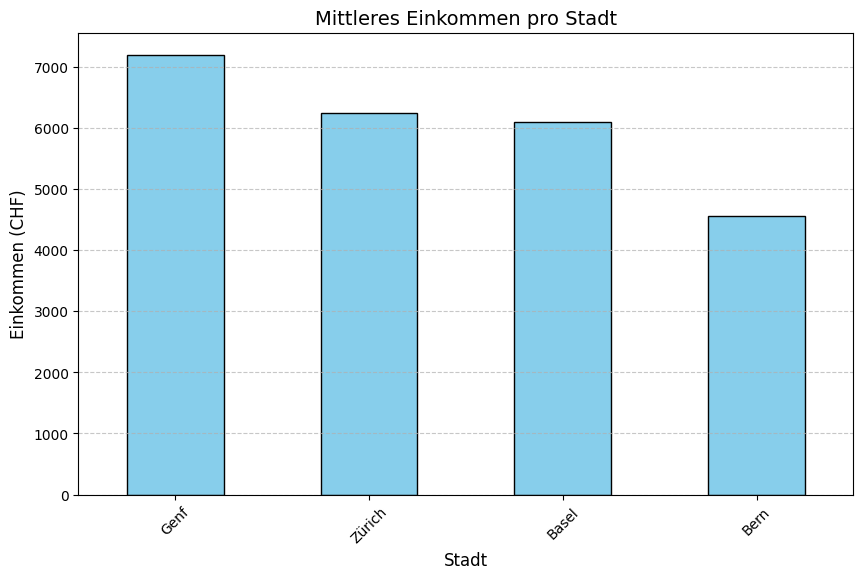

In [2]:
import matplotlib.pyplot as plt

# Daten gruppieren und Mittelwert berechnen
stadt_einkommen = df.groupby("Stadt")["Einkommen"].mean().sort_values(ascending=False)

# Visualisierung erstellen
plt.figure(figsize=(10, 6))
stadt_einkommen.plot(kind="bar", color="skyblue", edgecolor="black")

# Beschriftungen hinzufügen
plt.title("Mittleres Einkommen pro Stadt", fontsize=14)
plt.xlabel("Stadt", fontsize=12)
plt.ylabel("Einkommen (CHF)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

### Altersverteilung in 3 Kategorien

Nun soll die Spalte Alter in einem Histogramm mit 3 Bereichen (bins) erstellt werdne. Dazu müssen folgende Schritte ausgeführt werden:

- Start visualisierung
  ```
  plt.figure(figsize=(10, 6))
  ```

- Histogramm mit der Spalte Alter erstellen
  ```
  df["Alter"].plot(kind="hist", bins=3, color="orange", edgecolor="black")
  ```

- Diagramm beschriften
  ```
  plt.title("Altersverteilung im Datensatz")
  plt.xlabel("Alter")
  plt.ylabel("Anzahl Personen")
  plt.grid(axis="y", alpha=0.3)
  plt.show()
  ```

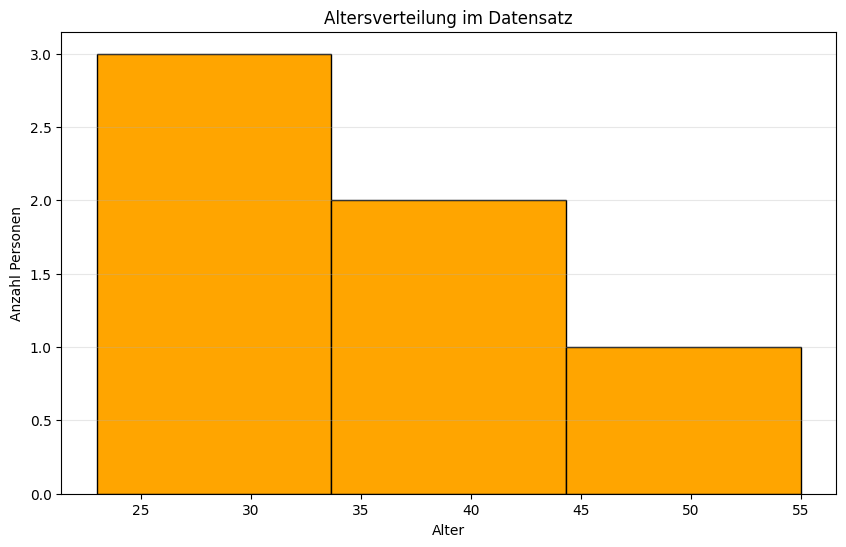

In [3]:
plt.figure(figsize=(10, 6))

df["Alter"].plot(kind="hist", bins=3, color="orange", edgecolor="black")

plt.title("Altersverteilung im Datensatz")
plt.xlabel("Alter")
plt.ylabel("Anzahl Personen")
plt.grid(axis="y", alpha=0.3)
plt.show()